z5658283 Haocheng Sheng

___________________________________________________________________________________________________________

In [1]:
import os, glob
import numpy as np
import cv2
import matplotlib.pyplot as plt

img_dir = r"C:\Users\ROG\Desktop\UNSW\COMP9517\lab1\COMP9517_26T1_Lab1_Images"

def load_images(folder):
    exts = ("png","jpg","jpeg","bmp","tif","tiff")
    paths = []
    for e in exts:
        paths += glob.glob(os.path.join(folder, f"*.{e}"))
    paths = sorted(paths)
    if len(paths) == 0:
        raise FileNotFoundError(f"No images found in: {folder}")
    imgs = []
    for p in paths:
        im = cv2.imread(p, cv2.IMREAD_COLOR)  # BGR
        if im is None:
            raise ValueError(f"Failed to read: {p}")
        imgs.append(im)
    return paths, imgs

def show_bgr(img, title="", figsize=(8,5)):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

paths, imgs = load_images(img_dir)

# ---------------------------------------------------------------------
# below is just for testing
# print("Loaded images:", len(imgs))
# print("Example files:", paths[:3])
# show_bgr(imgs[0], "Example noisy image (frame 1)")

___________________________________________________________________________________________________________

Task 1: Image Averaging for Noise Reduction 

While walking in UNSW campus, you decide to take a nice picture, only to discover that your camera is defective and produces very noisy images. You remember from the computer vision course that you can still create a nice picture simply by Averaging. So, you take 10 images from the same viewpoint (see the given .zip file on WebCMS3).

Calculate the average image of the 10 noisy images and display the result.

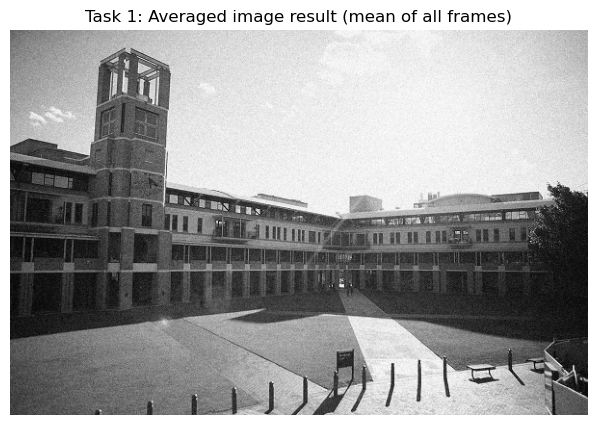

In [2]:
# 1) create an empty list to store float images
float_imgs = []

# 2) convert each image to float32 and put into the list
for im in imgs:
    float_im = im.astype(np.float32)
    float_imgs.append(float_im)

# 3) stack into a 4D array: (N, H, W, C)
stack = np.stack(float_imgs, axis=0)

# 4) compute the mean across the first dimension (N images)
avg = np.mean(stack, axis=0)

# 5) clip to valid pixel range and convert back to uint8 for display/saving
avg_pic = np.clip(avg, 0, 255).astype(np.uint8)

show_bgr(avg_pic, "Task 1: Averaged image result (mean of all frames)")

Q:

Theoretically, how much noise reduction should you be able to achieve this way? That is, by what factor should the standard deviation of the noise drop?

A:

Theoretically, if the noise in each image is independent, has a mean of zero, and the standard deviation of the noise in each image is the same sigma, then averaging N images pixel by pixel will reduce the variance of the noise to 1/N of its original value. 

Therefore, the standard deviation of the noise will become 1/√N of its original value; in other words, the standard deviation will decrease by a factor of √N. In this experiment, N equals 10, so theoretically the standard deviation of the noise should decrease by a factor of √10, approximately 3.16 times, meaning the standard deviation after averaging is approximately 0.316 of its original value.

---------------------------------------------------------------------

Q:

Practically, how much noise reduction did you actually achieve here? Note that this requires measuring the standard deviation of the pixel values within a region containing only random noise and no other image structures. The best region for this is the sky.

Measure the standard deviation within some rectangular region in the sky in one of the single noisy images and within the same region in the averaged image. Report the two standard deviations and the ratio of the former to the latter.

ROI std (single noisy image): 15.24785041809082
ROI std (averaged image):     4.813517093658447
Ratio (single / averaged):    3.167715024462893


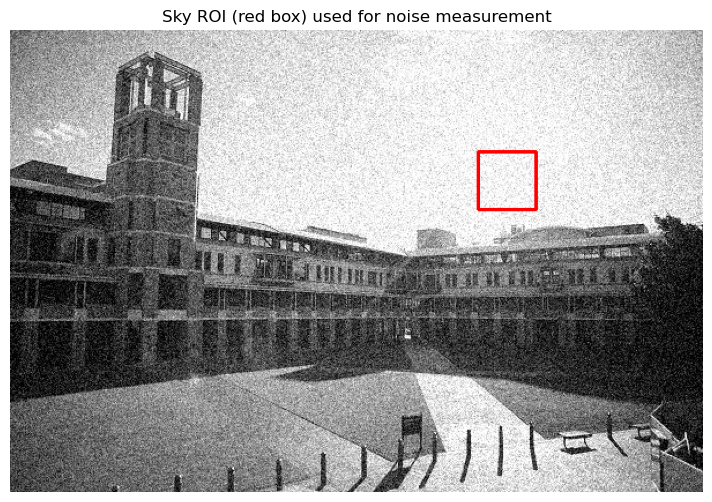

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1) choose one noisy image and the averaged image
single = imgs[0].astype(np.float32)
avg_f  = avg.astype(np.float32)

# 2) choose a SKY ROI (change these numbers)
#    rule: x2 > x1 and y2 > y1, and pick a smooth sky area
x1, x2 = 405, 455
y1, y2 = 105, 155

# 3) crop the ROI from both images
roi_single = single[y1:y2, x1:x2, :]
roi_avg    = avg_f[y1:y2, x1:x2, :]

# 4) convert ROI to grayscale and compute standard deviation
roi_single_gray = cv2.cvtColor(roi_single.astype(np.uint8), cv2.COLOR_BGR2GRAY).astype(np.float32)
roi_avg_gray    = cv2.cvtColor(np.clip(roi_avg,0,255).astype(np.uint8), cv2.COLOR_BGR2GRAY).astype(np.float32)

std_single = float(np.std(roi_single_gray))
std_avg    = float(np.std(roi_avg_gray))
ratio = std_single / std_avg if std_avg > 1e-12 else np.inf

print("ROI std (single noisy image):", std_single)
print("ROI std (averaged image):    ", std_avg)
print("Ratio (single / averaged):   ", ratio)

# 5) draw the red rectangle on the noisy image so you can show it in the report
vis = imgs[0].copy()
cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 0, 255), 2)  # red box in BGR
vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(vis_rgb)
plt.title("Sky ROI (red box) used for noise measurement")
plt.axis("off")
plt.show()

A:

In practice, I selected a rectangular region containing only the sky (avoiding cloud boundaries, building outlines, and other structures) from a single noisy image, and then selected the same region in the averaged image. I then converted this region to grayscale and calculated the standard deviation of the pixel grayscale values within that region to measure the noise intensity. 

The standard deviation of the single noisy image within this sky ROI was measured to be 15.2479, while the standard deviation of the averaged image within the same ROI was 4.8135. Therefore, the actual noise reduction factor (single image standard deviation divided by the average image standard deviation) was 3.1677. 

This result is very close to the theoretical expectation of a 3.16-fold reduction in standard deviation when averaging 10 images, indicating that the noise within this ROI mainly exhibits random fluctuations and is approximately independent between different frames, and the averaging operation can effectively suppress noise.

___________________________________________________________________________________________________________

Task 2: Difference of Gaussians (DoG) Filtering

We apply DoG filtering to the averaged image using two equivalent spatial-domain convolution approaches:

(1) Compute a single DoG kernel H1 - H2 then convolve once.
(2) Convolve with H1 and H2 separately and subtract the filtered images.

In [4]:
h1 = (1/16) * np.array([
    [0,0,0,0,0],
    [0,1,2,1,0],
    [0,2,4,2,0],
    [0,1,2,1,0],
    [0,0,0,0,0]
], dtype=np.float32)

h2 = (1/256) * np.array([
    [1,4,6,4,1],
    [4,16,24,16,4],
    [6,24,36,24,6],
    [4,16,24,16,4],
    [1,4,6,4,1]
], dtype=np.float32)

avg_gray = cv2.cvtColor(avg_pic, cv2.COLOR_BGR2GRAY).astype(np.float32)

# (1) one convolution with DoG kernel
dog_kernel = h1 - h2
g1 = cv2.filter2D(avg_gray, ddepth=cv2.CV_32F, kernel=dog_kernel)

# (2) two convolutions then subtract
f1 = cv2.filter2D(avg_gray, ddepth=cv2.CV_32F, kernel=h1)
f2 = cv2.filter2D(avg_gray, ddepth=cv2.CV_32F, kernel=h2)
g2 = f1 - f2

print("Max abs difference between g1 and g2:", float(np.max(np.abs(g1 - g2))))

Max abs difference between g1 and g2: 0.0


Filtering using the combined kernel (h1 minus h2) is theoretically equivalent to filtering with h1 and h2 individually and subtracting the results since convolution is linear and distributive. The two output pictures match identically because both methods employ the same filtering function and floating-point precision, resulting in a maximum absolute difference of 0.0.

---------------------------------------------------------------------

Take your average image from Task 1 and calculate its DoG-filtered version using the above two different approaches (1) and (2). Keep in mind that both approaches involve subtraction, and thus the resulting pixel values could be negative, so make sure to use data types that can
handle this correctly. 

Display the result images of the two different DoGfiltering approaches.

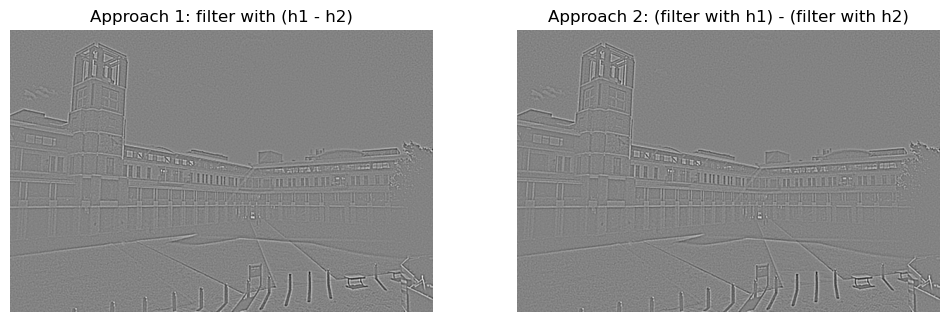

In [5]:
mn1, mx1 = float(np.min(g1)), float(np.max(g1))
mn2, mx2 = float(np.min(g2)), float(np.max(g2))

disp1 = ((g1 - mn1) / (mx1 - mn1 + 1e-12) * 255).astype(np.uint8)
disp2 = ((g2 - mn2) / (mx2 - mn2 + 1e-12) * 255).astype(np.uint8)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(disp1, cmap="gray")
plt.title("Approach 1: filter with (h1 - h2)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(disp2, cmap="gray")
plt.title("Approach 2: (filter with h1) - (filter with h2)")
plt.axis("off")
plt.show()

---------------------------------------------------------------------

Also answer the following question in your notebook:

While the two approaches achieve the same objective, they offer different advantages. Could you discuss the advantage of each approach relative to the other one?

A:

The two DoG approaches are equivalent. 

They are equivalent because convolution is linear and satisfies the distributive law: convolving the image once with the difference kernel (h1−h2) is equivalent to convolving it with h1 and h2 separately and then subtracting the results, so the mathematical results are the same. 

Based on this equivalence, their main differences lie in their implementation and computational advantages: Method 1 (synthesizing the DoG kernel before convolution) is more direct, requiring only one convolution operation, resulting in shorter code and fewer computational steps, suitable when you only care about the final DoG output and the kernel is fixed; while Method 2 (convolutioning separately and then subtracting) is more modular and flexible, allowing you to obtain both "smaller-scale smoothing results" and "larger-scale smoothing results" separately. 

Method 1 leans towards a simpler and more resource-efficient approach, while Method 2 leans towards a more reusable and more extensible way, although the final outputs of both should be completely consistent in theory and practice.

___________________________________________________________________________________________________________

Task 3: Unsharp Masking using DoG
We use one DoG output as a “detail/high-frequency” image, multiply it by 5, and add it back to the averaged image. This increases local contrast around intensity changes, so edges appear sharper. We may adjust brightness/contrast slightly to make the final image comparable to the averaged image.

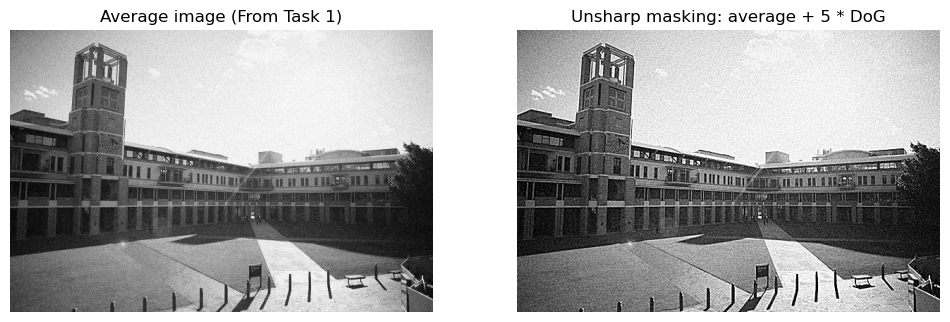

In [6]:
# 1) choose one DoG result (g1 or g2)
dog = g1  # or dog = g2

# 2) prepare the averaged image from Task 1 (grayscale, float32)
avg_gray = cv2.cvtColor(avg_pic, cv2.COLOR_BGR2GRAY).astype(np.float32)

# 3) multiply DoG by 5 (as required)
dog_5 = 5.0 * dog

# 4) add it back to the averaged image (unsharp masking)
sharp_float = avg_gray + dog_5  # still float32, may go outside [0,255]

# 5) clip to valid range and convert to uint8 for display
sharp_u8 = np.clip(sharp_float, 0, 255).astype(np.uint8)

# 6) display side-by-side
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(avg_gray, cmap="gray")
plt.title("Average image (From Task 1)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sharp_u8, cmap="gray")
plt.title("Unsharp masking: average + 5 * DoG")
plt.axis("off")

plt.show()

Q: 

Besides edge sharpness, what else has been amplified?

A:
In addition to making edges sharper, the unsharp masking process also amplifies random high-frequency variations, so noise becomes more visible.

---------------------------------------------------------------------

Q: 

Intuitive explanation:

A: 

Edges are high-frequency structures which rapid intensity changes, but random noise also appears as high-frequency variation. 
Therefore, when boost high-frequency components, both edges and noise become more visible.

___________________________________________________________________________________________________________